# **Batch Gradient Descent vs Stochastic Gradient Descent**

This experiment compares two fundamentally different optimization strategies:

- **Batch Gradient Descent (BGD)** — deterministic, smooth updates
- **Stochastic Gradient Descent (SGD)** — noisy, high-variance updates

Even though logistic regression is a convex problem, the optimization path differs significantly.

In [11]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from src.model import LogisticRegression
from src.optimizers.batch_gd import BatchGradientDescent
from src.optimizers.stochastic_gd import StochasticGradientDescent

from src.utils.data import generate_dataset, standardize
from src.utils.seed import set_seed

In [13]:
def smooth_loss(losses, window=50):
    smoothed = []
    for i in range(0, len(losses), window):
        smoothed.append(np.mean(losses[i:i+window]))
    return smoothed

## **Dataset**

We generate a controlled synthetic dataset:

- 500 samples
- 20 features

The same dataset and initialization will be used across optimizers to ensure a fair comparison.

In [14]:
set_seed(42)

X, y = generate_dataset()
X = standardize(X)

## **Training Configuration**

To isolate optimizer behavior:

- Same learning rate
- Same initialization
- Same dataset

This ensures differences arise purely from optimization strategy.

In [15]:
# Batch GD
set_seed(42)
model_batch = LogisticRegression(n_features=X.shape[1])
optimizer_batch = BatchGradientDescent(lr=0.005, epochs=50)

loss_batch = optimizer_batch.train(model_batch, X, y)


# SGD
set_seed(42)
model_sgd = LogisticRegression(n_features=X.shape[1])
optimizer_sgd = StochasticGradientDescent(lr=0.01, epochs=5)

loss_sgd = optimizer_sgd.train(model_sgd, X, y)

## **Loss Trajectory Comparison**

Key expectation:

- Batch GD -> smooth, monotonic decrease
- SGD -> noisy, fluctuating trajectory

This noise arises due to high variance in gradient estimates.

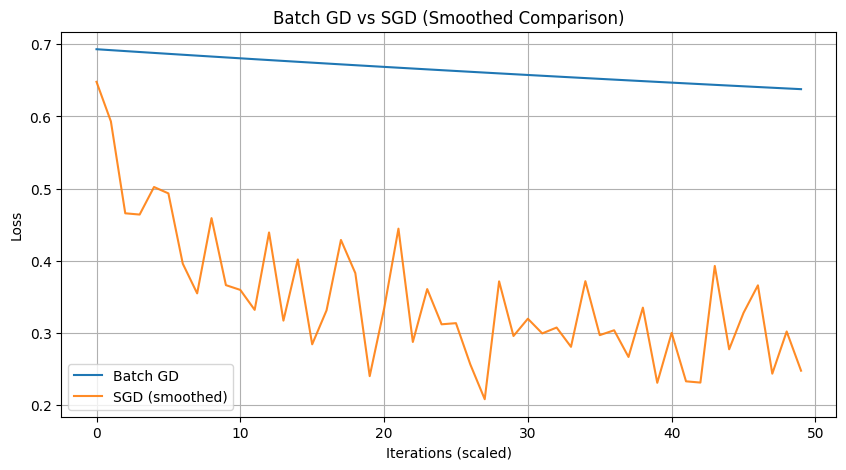

In [16]:
loss_sgd_smooth = smooth_loss(loss_sgd, window=50)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_batch, label="Batch GD")
ax.plot(loss_sgd_smooth, label="SGD (smoothed)", alpha=0.9)

ax.set_xlabel("Iterations (scaled)")
ax.set_ylabel("Loss")
ax.set_title("Batch GD vs SGD (Smoothed Comparison)")
ax.legend()
ax.grid()

from src.utils.io import ensure_dir
ensure_dir("../experiments")

fig.savefig(
    "../experiments/loss_comparison_smoothed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

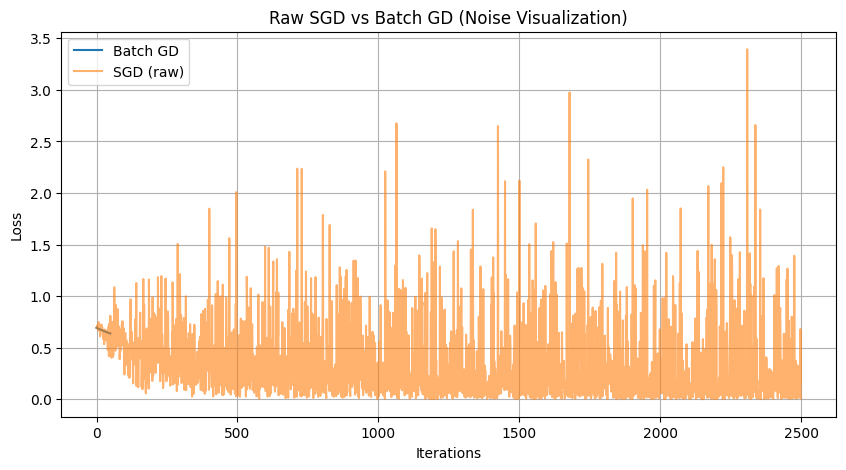

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_batch, label="Batch GD")
ax.plot(loss_sgd, label="SGD (raw)", alpha=0.6)

ax.set_xlabel("Iterations")
ax.set_ylabel("Loss")
ax.set_title("Raw SGD vs Batch GD (Noise Visualization)")
ax.legend()
ax.grid()

ensure_dir("../experiments")

fig.savefig(
    "../experiments/loss_raw_noise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

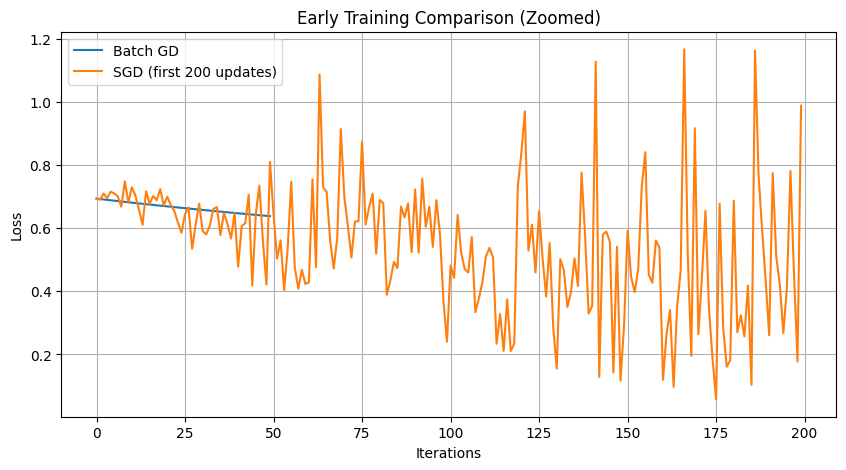

In [18]:
N = 200

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(loss_batch[:50], label="Batch GD")
ax.plot(loss_sgd[:N], label="SGD (first 200 updates)")

ax.set_xlabel("Iterations")
ax.set_ylabel("Loss")
ax.set_title("Early Training Comparison (Zoomed)")
ax.legend()
ax.grid()

ensure_dir("../experiments")

fig.savefig(
    "../experiments/loss_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Observations**

1. **Batch Gradient Descent**
   - Smooth convergence
   - Stable updates
   - Predictable trajectory

2. **Stochastic Gradient Descent**
   - Highly noisy updates
   - Does not strictly decrease every step
   - Still trends downward overall

## Key Insight

Even for convex problems, optimization dynamics differ significantly:

- SGD introduces noise -> can help exploration
- Batch GD provides stability -> but slower updates

This highlights the trade-off between **variance and stability**.